# What does an energy community pay, and under which tariff?

Fifty households are drawn from four Fluvius datasets and treated as one energy community.
Some have PV, some add an EV or a heat pump, ten have a 30 kWh battery. The whole community
is then settled over the full year under four commercial arrangements:

| Scenario | PV owners | Everyone else |
|---|---|---|
| **Redni** | `GENI_SAMO_REDNI` (samooskrba) | `GENI_REDNI` (dobava) |
| **Aktivni** | `GENI_SAMO_AKTIVNI` (4-tariff) | `GENI_AKTIVNI` |
| **Dinamični** | `GENI_SAMO_DINAMICNI` (SIPX + pribitek) | `GENI_DINAMICNI` |
| **Souporaba** | oddajniki, 40 % of surplus shared | prejemniki |

### Why two price lists per scenario

`si_paketi.preveri_paket` rejects a samooskrba list for a household with no PV device
(`zahteva_pv=True`). The twenty plain `Fluvius` households therefore take the supplier's
plain supply twin of the same list — same supplier, same price family, and every combination
stays a real offer. All 200 (household, scenario) pairs are validated in section 2.

### The four things this answers

1. What the community pays **as a whole**, split into energy / network / fixed / credit.
2. Its **annual peak power** — the coincident peak of the summed net import, and how far
   that sits below the sum of the individual peaks.
3. Who the **extremes** are — cheapest and dearest household — and what is happening there.
4. How much of the answer depends on **owning a battery**.

All study logic lives in `Community_Study.py`, so this notebook and any batch run cannot
drift apart.

In [1]:
### Imports
import importlib
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter

import Community_Study as cs
cs = importlib.reload(cs)

print("Community_Study loaded.")

Community_Study loaded.


## 1. Configuration

In [2]:
### Study configuration, read from the module
MEMBERS = cs.build_community()
RUN_DISPATCH = False       # True -> re-solve the battery households (~5 min on 10 workers)
N_WORKERS = 10

battery_members = [m for m in MEMBERS if m.has_battery]

print(f"{'Members':24s}{len(MEMBERS)}")
for dataset, ids, has_pv, battery_ids in cs.COMMUNITY_SPEC:
    ids = list(ids)
    print(f"{'  ' + dataset:24s}{len(ids):3d} households"
          f"{'  PV' if has_pv else '    '}"
          f"{'  ' + str(len(battery_ids)) + ' x 30 kWh battery' if battery_ids else ''}")
print(f"{'Batteries':24s}{len(battery_members)} x {cs.BATTERY_CAPACITY_KWH:.0f} kWh"
      f"  (C-rate {cs.C_RATE}, eta {cs.CHARGE_EFFICIENCY})")
print(f"{'Community battery':24s}{cs.COMMUNITY_BATTERY_KWH:.0f} kWh (not modelled)")
print(f"{'Pricing year':24s}{cs.PRICING_REFERENCE_YEAR}")
print(f"{'Peak reset':24s}{cs.PEAK_RESET_MONTHS}")
print(f"{'Solver gap / limit':24s}{cs.hc.FULL_PERIOD_GAP_REL} / {cs.hc.FULL_PERIOD_TIME_LIMIT_S}s")
print(f"{'Souporaba':24s}delez {cs.SOUPORABA_DELEZ:.0%}, "
      f"cena {cs.SOUPORABA_CENA_EUR_KWH} EUR/kWh, {cs.SOUPORABA_SERVICE_ID}")
print()
for name, cfg in cs.SCENARIOS.items():
    print(f"  {cfg['label']:12s} PV: {cfg['pv_paket']:22s} other: {cfg['nonpv_paket']}")

Members                 50
  Fluvius                20 households    
  Fluvius_PV             10 households  PV  5 x 30 kWh battery
  Fluvius_PV_EV          10 households  PV
  Fluvius_PV_HP          10 households  PV  5 x 30 kWh battery
Batteries               10 x 30 kWh  (C-rate 0.5, eta 0.95)
Community battery       0 kWh (not modelled)
Pricing year            2026
Peak reset              None
Solver gap / limit      0.001 / 900s
Souporaba               delez 40%, cena 0.05 EUR/kWh, GENI_SOUPORABA

  Redni        PV: GENI_SAMO_REDNI        other: GENI_REDNI
  Aktivni      PV: GENI_SAMO_AKTIVNI      other: GENI_AKTIVNI
  Dinamicni    PV: GENI_SAMO_DINAMICNI    other: GENI_DINAMICNI
  Souporaba    PV: GENI_SAMO_DINAMICNI    other: GENI_DINAMICNI


## 2. Build the community

In [3]:
### Load every member and compute its contracted power
t0 = time.time()
MEMBERS, DATA = cs.load_community(MEMBERS)
print(f"Loaded {len(DATA)} households in {time.time() - t0:.1f}s")

roster = pd.DataFrame([
    {
        "household_id": m.key,
        "segment": m.segment,
        "PV": m.has_pv,
        "Battery_kWh": m.battery_kwh,
        "Consumed_kWh": float(DATA[m.key][cs.CONSUMPTION_COLUMN].sum()),
        "Produced_kWh": float(DATA[m.key][cs.GENERATION_COLUMN].sum()),
        "Contracted_kW": m.contracted_power_kw[2],
    }
    for m in MEMBERS
])

print(f"\nIntervals per household: {set(len(d) for d in DATA.values())}")
print(f"Period: {next(iter(DATA.values())).index.min()} -> "
      f"{next(iter(DATA.values())).index.max()}")
roster.groupby("segment").agg(
    N=("household_id", "count"),
    Consumed_MWh=("Consumed_kWh", lambda s: s.sum() / 1000),
    Produced_MWh=("Produced_kWh", lambda s: s.sum() / 1000),
    Mean_Contracted_kW=("Contracted_kW", "mean"),
    Batteries=("Battery_kWh", lambda s: int((s > 0).sum())),
).round(2)

Loaded 50 households in 3.5s

Intervals per household: {35136}
Period: 2024-01-01 00:00:00+00:00 -> 2024-12-31 23:45:00+00:00


,N,Consumed_MWh,Produced_MWh,Mean_Contracted_kW,Batteries
segment,,,,,
Fluvius,20,60.30,0.00,3.60,0
Fluvius_PV,10,20.39,24.40,3.58,5
Fluvius_PV_EV,10,42.23,27.65,6.00,0
Fluvius_PV_HP,10,36.46,19.84,4.68,5


In [4]:
### Verification 1 + 2 -- data sanity and package validity
import sys
sys.path.append("New pricing functions")
from si_paketi import Gospodinjstvo, PAKETI, Shema, preveri_paket

lengths = {len(d) for d in DATA.values()}
smp_max = max(float(d[cs.PRICE_COLUMN].abs().quantile(0.95)) for d in DATA.values())
nans = sum(int(d[cs.PRICE_COLUMN].isna().sum()) for d in DATA.values())
assert len(lengths) == 1, f"ragged histories: {lengths}"
assert smp_max < 2.0, f"SMP looks like EUR/MWh, not EUR/kWh (q95={smp_max})"
assert nans == 0, f"{nans} NaN prices"

failures = []
for m in MEMBERS:
    g = Gospodinjstvo(m.key, m.contracted_power_kw, ima_pv=m.has_pv,
                      shema_samooskrbe=Shema.NOVA if m.has_pv else Shema.BREZ,
                      meritve_15min=True)
    for scenario in cs.SCENARIOS:
        paket = PAKETI[cs.scenario_paket(scenario, m)]
        try:
            preveri_paket(paket, g, strogo=True)
        except Exception as exc:
            failures.append((m.key, scenario, repr(exc)))

print(f"1. {len(DATA)} households x {lengths.pop()} intervals, "
      f"SMP q95 {smp_max:.4f} EUR/kWh, {nans} NaNs -> OK")
print(f"2. {len(MEMBERS) * len(cs.SCENARIOS)} (household, scenario) package pairs, "
      f"{len(failures)} rejected by preveri_paket -> "
      f"{'OK' if not failures else 'FAILED'}")
for f in failures[:5]:
    print("   ", f)

1. 50 households x 35136 intervals, SMP q95 0.1716 EUR/kWh, 0 NaNs -> OK
2. 200 (household, scenario) package pairs, 0 rejected by preveri_paket -> OK


## 3. Battery dispatch

The ten battery households are dispatched by the shared perfect-foresight MILP
(`MILP_Benchmark.run_milp_benchmark`), whole year, opening and closing at 50 % SOC, solved to
`FULL_PERIOD_GAP_REL`. The `souporaba` scenario reuses the `dinamicni` dispatch — identical
package, identical environment, only the settlement differs.

Each trajectory is then reduced to the *equivalent* (consumption, generation) pair that
reproduces its net grid flow exactly, which is what lets one settlement engine serve battery
and non-battery members alike.

In [5]:
### Solve or load the dispatch cache
if RUN_DISPATCH:
    cs.run_batch_dispatch(MEMBERS, n_workers=N_WORKERS)

cached = sorted(cs.DISPATCH_DIR.glob("*.csv"))
expected = cs.dispatch_units(MEMBERS)
print(f"{len(cached)} cached trajectories, {len(expected)} expected.")
if len(cached) < len(expected):
    raise SystemExit(
        "Dispatch cache incomplete. Set RUN_DISPATCH = True, or run\n"
        "    .venv/bin/python Community_Study.py --workers 10"
    )

balance = cs.check_dispatch_balance()
print("\nVerification 3 -- SOC recursion, bounds, curtailment, exclusivity")
print(f"  max |SOC residual|      {balance['Max_SOC_Residual_kWh'].max():.2e} kWh")
print(f"  SOC within [0, cap]     {balance['SOC_in_Bounds'].all()}")
print(f"  spill <= generation     {balance['Spill_within_Generation'].all()}")
print(f"  no simultaneous ch/dis  {balance['No_Simultaneous_ChDis'].all()}")
print(f"  -> {'OK' if balance['OK'].all() else 'FAILED'}")

drift = balance["SOC_Drift_kWh"].abs().max()
print(f"\n  max |SOC drift| over the year {drift:.3f} kWh "
      f"({100 * drift / cs.BATTERY_CAPACITY_KWH:.2f} % of capacity)")
print("  The terminal SOC is a floor (E[N] >= 50 %), not an equality, so a solve may")
print("  finish slightly above where it started. Any such surplus is stored energy the")
print("  household paid for and did not use -- it flatters the battery, never the")
print("  reverse, and at this magnitude it is far below the 0.1 % solver gap.")

30 cached trajectories, 30 expected.



Verification 3 -- SOC recursion, bounds, curtailment, exclusivity
  max |SOC residual|      1.00e-06 kWh
  SOC within [0, cap]     True
  spill <= generation     True
  no simultaneous ch/dis  True
  -> OK

  max |SOC drift| over the year 0.137 kWh (0.46 % of capacity)
  The terminal SOC is a floor (E[N] >= 50 %), not an equality, so a solve may
  finish slightly above where it started. Any such surplus is stored energy the
  household paid for and did not use -- it flatters the battery, never the
  reverse, and at this magnitude it is far below the 0.1 % solver gap.


## 4. Settlement

Scenarios 1–3 are priced interval by interval through `calculate_interval_price`, the same
dispatcher the environment and the MILP use. `souporaba` goes through
`si_obracun.obracun_souporabe`, settled **month by month** across the year and summed — the
power charge, the OVE/SPTE contribution and the excess-power penalty all reset monthly, so a
year cannot be settled in one call.

In [6]:
### Settle all four scenarios
t0 = time.time()
RESULTS = cs.run_all_scenarios(MEMBERS, DATA, verbose=True)
print(f"\nAll scenarios settled in {time.time() - t0:.1f}s")

PROFILES = {s: cs.scenario_profiles(MEMBERS, DATA, s) for s in cs.SCENARIOS}
HOUSEHOLDS = cs.per_household(RESULTS)

cs.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
HOUSEHOLDS.to_csv(cs.RESULTS_DIR / "per_household.csv", index=False)
print(f"{len(HOUSEHOLDS)} (scenario, household) rows -> "
      f"{cs.RESULTS_DIR / 'per_household.csv'}")

--- redni ---


    settled in 64.2s


--- aktivni ---


    settled in 64.9s


--- dinamicni ---


...

  souporaba 2024-11 settled


  souporaba 2024-12 settled


    settled in 12.2s



All scenarios settled in 206.2s


200 (scenario, household) rows -> /Users/summerscholl/Documents/Andraz/Energy_Community/Results/Community_Study/per_household.csv


## 5. The community as a whole

In [7]:
### What the community pays, per scenario
TOTALS = cs.community_totals(RESULTS)

totals_display = TOTALS[[
    "Scenario", "Total_EUR", "EUR_per_MWh", "Variable_Gross_EUR",
    "Fixed_EUR", "Credit_EUR", "Consumed_MWh",
]].rename(columns={
    "Total_EUR": "Total [EUR/a]",
    "EUR_per_MWh": "Unit [EUR/MWh]",
    "Variable_Gross_EUR": "Energy + network [EUR]",
    "Fixed_EUR": "Fixed [EUR]",
    "Credit_EUR": "Export credit [EUR]",
    "Consumed_MWh": "Consumed [MWh]",
})
print("Gross bill minus export credit. The samooskrba path nets the export inside")
print("the interval and the souporaba path deducts it after VAT, so both are put on")
print("a common gross basis; the reconciliation is checked in the next cell.")
totals_display.round(2)

Gross bill minus export credit. The samooskrba path nets the export inside
the interval and the souporaba path deducts it after VAT, so both are put on
a common gross basis; the reconciliation is checked in the next cell.


,Scenario,Total [EUR/a],Unit [EUR/MWh],Energy + network [EUR],Fixed [EUR],Export credit [EUR],Consumed [MWh]
0,Redni,28883.86,181.24,22913.62,9166.64,3196.40,159.37
1,Aktivni,27061.34,169.80,29712.91,9166.64,11818.20,159.37
2,Dinamicni,23004.92,144.35,26915.38,9883.98,13794.43,159.37
3,Souporaba,39789.22,249.67,27557.74,22660.79,10429.32,159.37


In [8]:
### Community peak power over the year
peak_display = TOTALS[[
    "Scenario", "Community_Peak_kW", "Peak_At",
    "Sum_Individual_Peaks_kW", "Diversity_Factor",
]].rename(columns={
    "Community_Peak_kW": "Coincident peak [kW]",
    "Peak_At": "Occurs at (UTC)",
    "Sum_Individual_Peaks_kW": "Sum of individual peaks [kW]",
    "Diversity_Factor": "Diversity factor",
})

peak_check = cs.check_community_peak(RESULTS)
print("Verification 5 -- coincident peak <= sum of individual peaks, "
      f"timestamp reproduces: {peak_check['OK'].all() and peak_check['Timestamp_Reproduces'].all()}")
print("\nThe coincident peak is what the community's shared connection sees. The regulated")
print("power charge is billed per household per tariff block, so it is the RIGHT-hand column")
print("that drives the bill -- the gap between them is the value the community never captures.")
peak_display.round(3)

Verification 5 -- coincident peak <= sum of individual peaks, timestamp reproduces: True

The coincident peak is what the community's shared connection sees. The regulated
power charge is billed per household per tariff block, so it is the RIGHT-hand column
that drives the bill -- the gap between them is the value the community never captures.


/var/folders/39/ydgffyrd3m102wzr66n24xmr0000gr/T/ipykernel_91190/166413377.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  peak_display.round(3)


,Scenario,Coincident peak [kW],Occurs at (UTC),Sum of individual peaks [kW],Diversity factor
0,Redni,63.016,2024-01-06 13:30:00+00:00,303.305,0.208
1,Aktivni,152.522,2024-01-06 14:45:00+00:00,376.342,0.405
2,Dinamicni,152.839,2024-01-29 00:00:00+00:00,385.589,0.396
3,Souporaba,152.839,2024-01-29 00:00:00+00:00,385.589,0.396


In [9]:
### Energy balance of the community
cs.community_kpis(RESULTS).drop(columns=["scenario"]).round(2)

,Scenario,Consumed_MWh,Produced_MWh,Imported_MWh,Exported_MWh,Self_Sufficiency_pct,Self_Consumption_pct
0,Redni,159.37,71.89,147.80,59.30,7.90,17.51
1,Aktivni,159.37,71.89,209.58,113.71,-26.24,-58.17
2,Dinamicni,159.37,71.89,203.81,107.63,-22.43,-49.73
3,Souporaba,159.37,71.89,203.81,107.63,-22.43,-49.73


## 6. Who pays what

In [10]:
### Mean annual cost by segment and battery status
cs.by_segment(RESULTS).round(2)

,Scenario,segment,battery,N,Mean_EUR,Min_EUR,Max_EUR
0,Aktivni,Fluvius,no battery,20,643.24,235.34,2270.84
1,Aktivni,Fluvius_PV,battery,5,-315.97,-465.87,-165.63
2,Aktivni,Fluvius_PV,no battery,5,504.38,290.25,1104.16
3,Aktivni,Fluvius_PV_EV,no battery,10,907.02,389.56,1520.40
4,Aktivni,Fluvius_PV_HP,battery,5,251.53,-113.72,492.24
5,Aktivni,Fluvius_PV_HP,no battery,5,585.33,429.27,741.55
6,Dinamicni,Fluvius,no battery,20,627.01,248.20,2100.28
7,Dinamicni,Fluvius_PV,battery,5,-458.51,-591.52,-348.03
8,Dinamicni,Fluvius_PV,no battery,5,414.75,219.61,852.27
9,Dinamicni,Fluvius_PV_EV,no battery,10,772.92,271.98,1315.68


In [11]:
### Cheapest scenario for each household
pivot = HOUSEHOLDS.pivot_table(
    index=["segment", "household_id"], columns="Scenario", values="total_cost_eur"
)
order = [cs.SCENARIOS[s]["label"] for s in cs.SCENARIOS]
pivot = pivot.reindex(columns=order)
pivot["Best"] = pivot.idxmin(axis=1)
pivot["Spread [EUR]"] = pivot[order].max(axis=1) - pivot[order].min(axis=1)

print("How many households are cheapest under each scenario:")
print(pivot["Best"].value_counts().to_string())
pivot.round(2)

How many households are cheapest under each scenario:
Best
Dinamicni    24
Redni        21
Aktivni       5


Scenario                           Redni  Aktivni  Dinamicni  Souporaba  \
segment       household_id                                                
Fluvius       Fluvius_001         499.65   497.01     505.34     574.95   
              Fluvius_002         553.58   518.78     532.41     604.70   
              Fluvius_003         628.35   627.73     627.57     695.25   
              Fluvius_004         580.79   580.11     581.97     631.07   
              Fluvius_005         233.37   235.34     248.20     365.95   
              Fluvius_006         487.38   481.50     479.34     553.41   
              Fluvius_007         872.44   860.06     861.59     871.11   
              Fluvius_008         523.48   544.52     542.28     616.08   
              Fluvius_009         499.95   525.68     514.37     584.97   
              Fluvius_010         777.00   806.80     778.45     807.32   
              Fluvius_011         405.07   383.79     401.40     510.89   
              Fluvius_012         508.76   504.68     501.48     563.04   
              Fluvius_013        2204.69  2270.84    2100.28    2204.39   
              Fluvius_014         284.96   287.67     293.37     404.12   
              Fluvius_015         249.30   258.94     265.16     385.79   
              Fluvius_016        1061.83  1138.83    1016.17    1178.60   
              Fluvius_017         754.24   764.86     748.23     778.11   
              Fluvius_018         728.15   763.88     727.62     809.30   
              Fluvius_019         451.34   456.44     454.98     527.67   
              Fluvius_020         345.38   357.28     360.01     457.23   
Fluvius_PV    Fluvius_PV_001      283.95  -165.63    -348.03     841.54   
              Fluvius_PV_002      117.73  -358.26    -498.68     845.25   
              Fluvius_PV_003       35.32  -465.87    -591.52     854.21   
              Fluvius_PV_004      215.33  -244.19    -364.78    1205.50   
              Fluvius_PV_005      148.60  -345.87    -489.56     668.65   
              Fluvius_PV_006      889.39  1104.16     852.27    1027.16   
              Fluvius_PV_007      225.86   290.25     219.61     325.47   
              Fluvius_PV_008      436.12   507.29     474.07     556.23   
              Fluvius_PV_009      264.94   294.54     248.83     349.29   
              Fluvius_PV_010      290.82   325.65     278.98     379.01   
Fluvius_PV_EV Fluvius_PV_EV_001   872.43  1080.47     913.43    1099.81   
              Fluvius_PV_EV_002   509.63   574.58     535.95     621.92   
              Fluvius_PV_EV_003  1003.13  1160.48    1012.03    1199.69   
              Fluvius_PV_EV_004   443.65   552.26     471.24     560.55   
              Fluvius_PV_EV_005   677.31   784.89     697.00     790.54   
              Fluvius_PV_EV_006   977.51  1340.30    1095.42    1198.46   
              Fluvius_PV_EV_007   826.86  1036.21     892.35    1029.59   
              Fluvius_PV_EV_008   493.40   631.09     524.13     607.26   
              Fluvius_PV_EV_009  1299.15  1520.40    1315.68    1586.33   
              Fluvius_PV_EV_010   314.26   389.56     271.98     453.64   
Fluvius_PV_HP Fluvius_PV_HP_001   758.48   368.25     176.57    1235.21   
              Fluvius_PV_HP_002   683.32   304.93     102.17    1372.33   
              Fluvius_PV_HP_003   876.42   492.24     255.83    1629.98   
              Fluvius_PV_HP_004   672.32   205.96      59.60    1321.17   
              Fluvius_PV_HP_005   332.40  -113.72    -283.74     730.05   
              Fluvius_PV_HP_006   558.85   693.08     616.35     704.56   
              Fluvius_PV_HP_007   393.25   429.27     392.61     501.28   
              Fluvius_PV_HP_008   631.77   741.55     650.63     749.45   
              Fluvius_PV_HP_009   485.00   471.54     444.07     593.02   
              Fluvius_PV_HP_010   516.94   591.22     540.22     628.09   

Scenario                              Best  Spread [EUR]  
segment       household_id              

In [12]:
### Verification 4 -- a battery must never make the bill worse
COUNTERFACTUAL = cs.battery_counterfactual(MEMBERS, DATA, RESULTS)
violations = COUNTERFACTUAL[COUNTERFACTUAL["Saving_EUR"] < 0]
print(f"{len(COUNTERFACTUAL)} (battery household, scenario) pairs re-settled at 0 kWh; "
      f"{len(violations)} where the battery lost money -> "
      f"{'OK' if violations.empty else 'FAILED'}")
if not violations.empty:
    display(violations)

COUNTERFACTUAL.groupby("Scenario")[["No_Battery_EUR", "With_Battery_EUR", "Saving_EUR"]] \
    .agg(["mean", "min", "max"]).round(2)

30 (battery household, scenario) pairs re-settled at 0 kWh; 0 where the battery lost money -> OK


No_Battery_EUR                  With_Battery_EUR                  \
                    mean     min      max             mean     min     max   
Scenario                                                                     
Aktivni           609.46  162.49  1146.62           -32.22 -465.87  492.24   
Dinamicni         531.49  109.37   999.17          -198.21 -591.52  255.83   
Redni             502.98  107.66   951.47           412.39   35.32  876.42   

          Saving_EUR                  
                mean     min     max  
Scenario                              
Aktivni       641.68  523.14  708.94  
Dinamicni     729.70  637.21  789.16  
Redni          90.60   28.21  141.46

## 7. The extremes

The cheapest and the dearest household in each scenario, and what is driving each.

In [13]:
### Highest- and lowest-cost household per scenario
EXTREMES = cs.extremes(RESULTS)
EXTREMES[[
    "Scenario", "Extreme", "household_id", "segment", "Cost_EUR", "EUR_per_MWh",
    "Consumed_kWh", "Produced_kWh", "Battery_kWh", "Contracted_kW", "Peak_kW",
    "Peak_over_Contract",
]].round(2)

,Scenario,Extreme,household_id,segment,Cost_EUR,EUR_per_MWh,Consumed_kWh,Produced_kWh,Battery_kWh,Contracted_kW,Peak_kW,Peak_over_Contract
0,Redni,lowest,Fluvius_PV_003,Fluvius_PV,35.32,31.50,1121.00,2728.03,30.0,1.83,1.83,1.00
1,Redni,highest,Fluvius_013,Fluvius,2204.69,177.47,12422.63,0.00,0.0,6.54,9.81,1.50
2,Aktivni,lowest,Fluvius_PV_003,Fluvius_PV,-465.87,-415.59,1121.00,2728.03,30.0,1.83,11.42,6.23
3,Aktivni,highest,Fluvius_013,Fluvius,2270.84,182.80,12422.63,0.00,0.0,6.54,9.81,1.50
4,Dinamicni,lowest,Fluvius_PV_003,Fluvius_PV,-591.52,-527.67,1121.00,2728.03,30.0,1.83,11.75,6.41
5,Dinamicni,highest,Fluvius_013,Fluvius,2100.28,169.07,12422.63,0.00,0.0,6.54,9.81,1.50
6,Souporaba,lowest,Fluvius_PV_007,Fluvius_PV,325.47,183.83,1770.47,2656.02,0.0,2.22,3.33,1.50
7,Souporaba,highest,Fluvius_013,Fluvius,2204.39,177.45,12422.63,0.00,0.0,6.54,9.81,1.50


In [14]:
### Souporaba: what was shared, used and forfeited
sou = RESULTS["souporaba"]["summary"]
sou_members = sou[sou["household_id"] != "GROUP"]

conservation = cs.check_souporaba_conservation(RESULTS["souporaba"])
print(f"Verification 6 -- shared energy conserved every month: "
      f"{conservation['OK'].all()}")
print(f"  max residual {conservation['Residual_kWh'].abs().max():.3f} kWh "
      f"vs rounding bound {conservation['Rounding_Bound_kWh'].max():.3f} kWh")
print("  (si_obracun rounds every diagnostic to 2 dp, so the balance cannot close")
print("   exactly; the bound is 0.005 kWh x the number of rounded figures)")

shared = float(sou_members.loc[sou_members["role"] == "oddajnik", "deljeno_kwh"].sum())
used = float(sou_members.loc[sou_members["role"] == "prejemnik", "deljeno_kwh"].sum())
wasted = float(sou_members["neizrabljeno_kwh"].sum())
print(f"\nShared by senders   {shared:9.0f} kWh")
print(f"Used by receivers   {used:9.0f} kWh  ({100 * used / shared:.1f} %)")
print(f"Forfeited           {wasted:9.0f} kWh  ({100 * wasted / shared:.1f} %)")
print("\nForfeited energy is not credited and does not carry forward -- it accrues to")
print("the receiver's supplier. It is the cost of sharing a fixed fraction of surplus")
print("rather than a demand-following one: 30 senders push their midday peak at 20")
print("receivers who are mostly not home, and most of it never lands.")

sou_members.groupby("role")[
    ["total_cost_eur", "prevzeto_kwh", "oddano_kwh", "deljeno_kwh", "neizrabljeno_kwh"]
].agg(["count", "sum", "mean"]).round(2)

Verification 6 -- shared energy conserved every month: True
  max residual 0.020 kWh vs rounding bound 0.350 kWh
  (si_obracun rounds every diagnostic to 2 dp, so the balance cannot close
   exactly; the bound is 0.005 kWh x the number of rounded figures)

Shared by senders       43053 kWh
Used by receivers       12353 kWh  (28.7 %)
Forfeited               30701 kWh  (71.3 %)

Forfeited energy is not credited and does not carry forward -- it accrues to
the receiver's supplier. It is the cost of sharing a fixed fraction of surplus
rather than a demand-following one: 30 senders push their midday peak at 20
receivers who are mostly not home, and most of it never lands.


total_cost_eur                   prevzeto_kwh                      \
                   count       sum    mean        count        sum     mean   
role                                                                          
oddajnik              30  25665.28  855.51           30  143516.94  4783.90   
prejemnik             20  14123.94  706.20           20   60292.87  3014.64   

          oddano_kwh                    deljeno_kwh                     \
               count       sum     mean       count       sum     mean   
role                                                                     
oddajnik          30  64579.73  2152.66          30  43053.14  1435.10   
prejemnik         20      0.00     0.00          20  12352.51   617.63   

          neizrabljeno_kwh                     
                     count       sum     mean  
role                                           
oddajnik                30      0.00     0.00  
prejemnik               20  30700.71  1535.04

## 8. Plots

In [15]:
### Shared chart styling
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#8b8a84", "#fcfcfb"
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
BLUE_RAMP = LinearSegmentedColormap.from_list("blues", BLUES)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10,
    "legend.frameon": False, "figure.dpi": 110,
})

SCEN_ORDER = list(cs.SCENARIOS)
LABEL = {s: cs.SCENARIOS[s]["label"] for s in SCEN_ORDER}

# Scenarios get the four categorical hues; segments get steps of one hue. The
# two encodings never share a chart, and keeping them in different colour
# families means a blue dot is never mistaken for "the Dinamicni scenario".
SCEN_COLOR = {s: SERIES[i] for i, s in enumerate(SCEN_ORDER)}
SEGMENTS = [d for d, *_ in cs.COMMUNITY_SPEC]
SEG_STEPS = [1, 3, 5, 6]
SEG_COLOR = {seg: BLUES[SEG_STEPS[i % len(SEG_STEPS)]] for i, seg in enumerate(SEGMENTS)}
EUR = FuncFormatter(lambda v, _: f"{v:,.0f}")

def finish(ax, title, subtitle=None, xlabel=None, ylabel=None):
    # The subtitle sits in the space the title pad opens up; without the extra
    # pad the two render on top of each other.
    ax.set_title(title, pad=26 if subtitle else 12)
    if subtitle:
        ax.text(0, 1.015, subtitle, transform=ax.transAxes,
                color=MUTED, fontsize=9, va="bottom")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)

print(f"Style ready. {len(SCEN_ORDER)} scenarios, {len(SEGMENTS)} segments.")

Style ready. 4 scenarios, 4 segments.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


Supply + network + levies + fees - credit reproduces the billed total to 9.00e-06 EUR


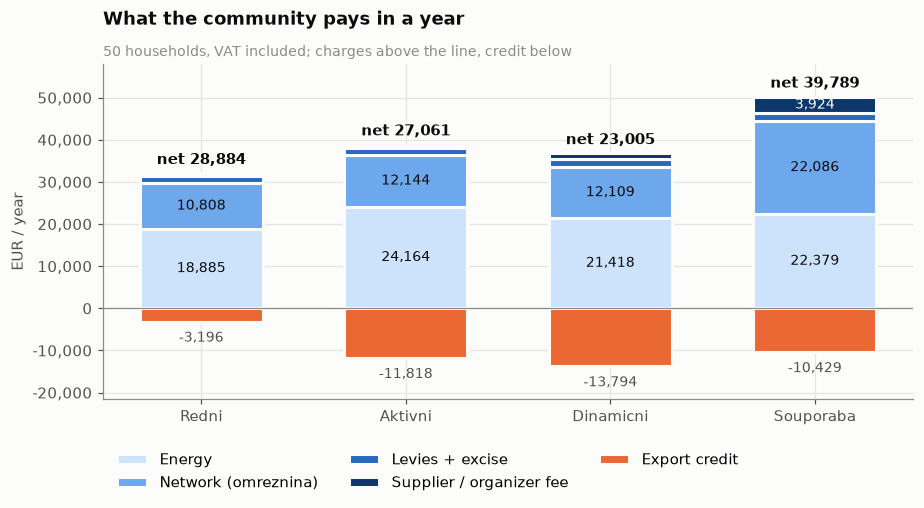

,Scenario,Supply_EUR,Network_EUR,Levies_EUR,Supplier_Fee_EUR,Credit_EUR,Total_EUR,Network_share_pct
0,Redni,18885.3,10808.3,1661.9,724.7,3196.4,28883.9,33.7
1,Aktivni,24163.5,12144.0,1847.3,724.7,11818.2,27061.3,31.2
2,Dinamicni,21418.2,12109.1,1830.0,1442.0,13794.4,23004.9,32.9
3,Souporaba,22379.1,22085.8,1830.1,3923.5,10429.3,39789.2,44.0


In [16]:
### Community annual cost by scenario, split by who is paid
resid = TOTALS["Category_Residual_EUR"].abs().max()
print(f"Supply + network + levies + fees - credit reproduces the billed total to {resid:.2e} EUR")
# A tenth of a cent, not the 1e-6 the two-way split is held to: this one adds up
# eight items per interval across 50 households and a year, so float noise
# accumulates about four orders of magnitude further.
assert resid < 1e-3, "the cost split does not reconcile with the billed total"

# Network and energy are the two halves worth telling apart: the network side is
# regulated and identical for every supplier, the energy side is what a package
# actually competes on. The old "energy + network / fixed" split hid the network
# power charge inside "fixed", which put the two on the wrong sides of the line.
parts = [
    ("Supply_EUR", "Energy", BLUES[0]),
    ("Network_EUR", "Network (omreznina)", BLUES[2]),
    ("Levies_EUR", "Levies + excise", BLUES[4]),
    ("Supplier_Fee_EUR", "Supplier / organizer fee", BLUES[6]),
]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(TOTALS))
bottom = np.zeros(len(TOTALS))
gross = TOTALS["Gross_EUR"].to_numpy(dtype=float)

for col, label, color in parts:
    vals = TOTALS[col].fillna(0.0).to_numpy(dtype=float)
    ax.bar(x, vals, bottom=bottom, width=0.6, label=label,
           color=color, edgecolor=SURFACE, linewidth=2)
    # In-slice figure only where the slice is tall enough to hold it.
    for xi, val, base, tot in zip(x, vals, bottom, gross):
        if val > 0.07 * tot:
            ax.annotate(f"{val:,.0f}", (xi, base + val / 2), ha="center", va="center",
                        fontsize=9, color=SURFACE if color in BLUES[4:] else INK)
    bottom += vals

credit = -TOTALS["Credit_EUR"].fillna(0.0).to_numpy(dtype=float)
ax.bar(x, credit, width=0.6, label="Export credit", color=SERIES[1],
       edgecolor=SURFACE, linewidth=2)
for xi, val in zip(x, credit):
    ax.annotate(f"{val:,.0f}", (xi, val), xytext=(0, -13), textcoords="offset points",
                ha="center", fontsize=9, color=INK_2)

for xi, total in zip(x, TOTALS["Total_EUR"]):
    ax.annotate(f"net {total:,.0f}", (xi, bottom[xi]), xytext=(0, 6),
                textcoords="offset points", ha="center",
                fontsize=10, fontweight="semibold", color=INK)

ax.axhline(0, color=MUTED, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(TOTALS["Scenario"])
ax.yaxis.set_major_formatter(EUR)
ax.margins(y=0.12)
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, -0.12))
finish(ax, "What the community pays in a year",
       f"{len(MEMBERS)} households, VAT included; charges above the line, credit below",
       ylabel="EUR / year")
plt.tight_layout()
plt.show()

TOTALS[["Scenario", "Supply_EUR", "Network_EUR", "Levies_EUR", "Supplier_Fee_EUR",
        "Credit_EUR", "Total_EUR"]].assign(
    Network_share_pct=100 * TOTALS["Network_EUR"] / TOTALS["Gross_EUR"]).round(1)

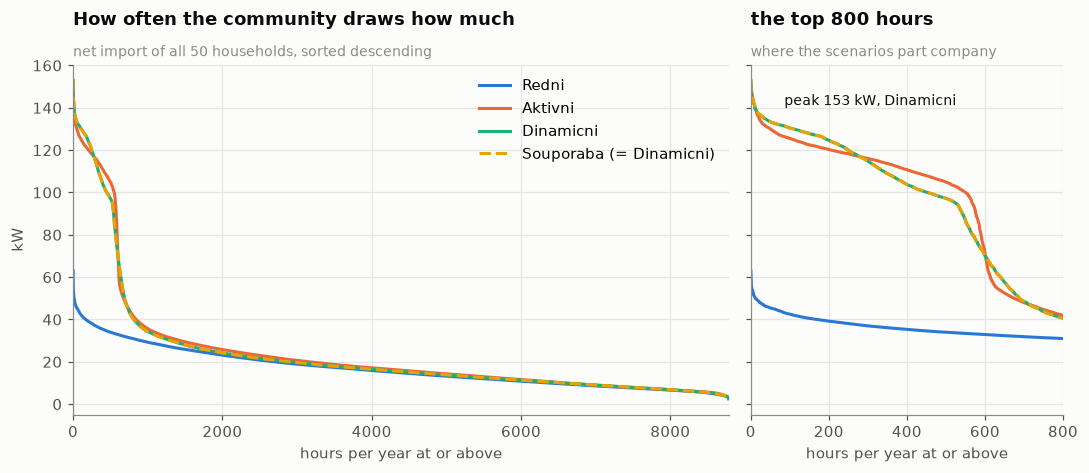

In [17]:
### Community net-import duration curve
ZOOM_HOURS = 800
interval_hours = 24.0 / cs.STEPS_PER_DAY

fig, (ax, axz) = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True,
                              gridspec_kw={"width_ratios": [2.1, 1]})

for scenario in SCEN_ORDER:
    profile = RESULTS[scenario]["community_profile"]["community_import_kw"]
    sorted_kw = np.sort(profile.to_numpy(dtype=float))[::-1]
    hours = (np.arange(len(sorted_kw)) + 1) * interval_hours
    # Souporaba runs the dinamicni dispatch, so its curve lies exactly on top of
    # it -- dashed, or whichever is drawn first disappears.
    style = {"color": SCEN_COLOR[scenario], "linewidth": 2,
             "linestyle": "--" if scenario == "souporaba" else "-"}
    label = LABEL[scenario] + (" (= Dinamicni)" if scenario == "souporaba" else "")
    ax.plot(hours, sorted_kw, label=label, **style)
    axz.plot(hours, sorted_kw, **style)

peak_row = TOTALS.loc[TOTALS["Community_Peak_kW"].idxmax()]
axz.annotate(f"peak {peak_row['Community_Peak_kW']:.0f} kW, {peak_row['Scenario']}",
             (0, peak_row["Community_Peak_kW"]), xytext=(22, -16),
             textcoords="offset points", color=INK, fontsize=9)

ax.set_xlim(0, 8784)
ax.set_xticks(np.arange(0, 8785, 2000))
ax.legend(loc="upper right")
finish(ax, "How often the community draws how much",
       "net import of all 50 households, sorted descending",
       xlabel="hours per year at or above", ylabel="kW")

axz.set_xlim(0, ZOOM_HOURS)
axz.set_xticks(np.arange(0, ZOOM_HOURS + 1, 200))
finish(axz, f"the top {ZOOM_HOURS} hours", "where the scenarios part company",
       xlabel="hours per year at or above")
plt.tight_layout()
plt.show()

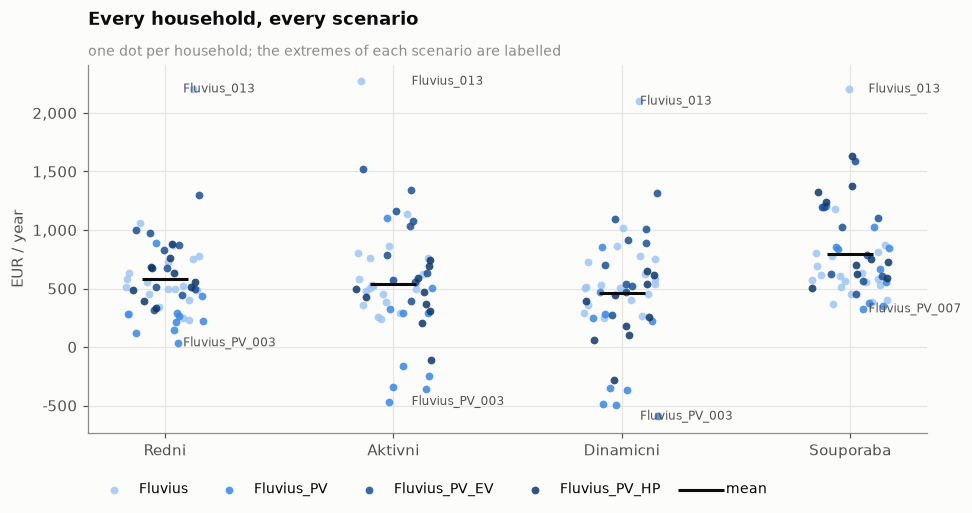

In [18]:
### Per-household annual cost, by scenario
fig, ax = plt.subplots(figsize=(9, 4.8))
rng = np.random.default_rng(0)

for i, scenario in enumerate(SCEN_ORDER):
    subset = HOUSEHOLDS[HOUSEHOLDS["scenario"] == scenario]
    for seg in SEGMENTS:
        seg_rows = subset[subset["segment"] == seg]
        jitter = rng.uniform(-0.17, 0.17, len(seg_rows))
        ax.scatter(np.full(len(seg_rows), i) + jitter, seg_rows["total_cost_eur"],
                   s=26, color=SEG_COLOR[seg], alpha=0.85, linewidth=0,
                   label=seg if i == 0 else None)
    ax.scatter([i], [subset["total_cost_eur"].mean()], marker="_", s=900,
               color=INK, linewidth=2, zorder=5,
               label="mean" if i == 0 else None)

for _, row in EXTREMES.iterrows():
    xi = SCEN_ORDER.index(row["scenario"])
    ax.annotate(row["household_id"], (xi, row["Cost_EUR"]), xytext=(12, 0),
                textcoords="offset points", fontsize=8, color=INK_2, va="center")

ax.set_xticks(range(len(SCEN_ORDER)))
ax.set_xticklabels([LABEL[s] for s in SCEN_ORDER])
ax.yaxis.set_major_formatter(EUR)
ax.legend(ncol=5, loc="upper left", bbox_to_anchor=(0, -0.10), fontsize=9)
finish(ax, "Every household, every scenario",
       "one dot per household; the extremes of each scenario are labelled",
       ylabel="EUR / year")
plt.tight_layout()
plt.show()

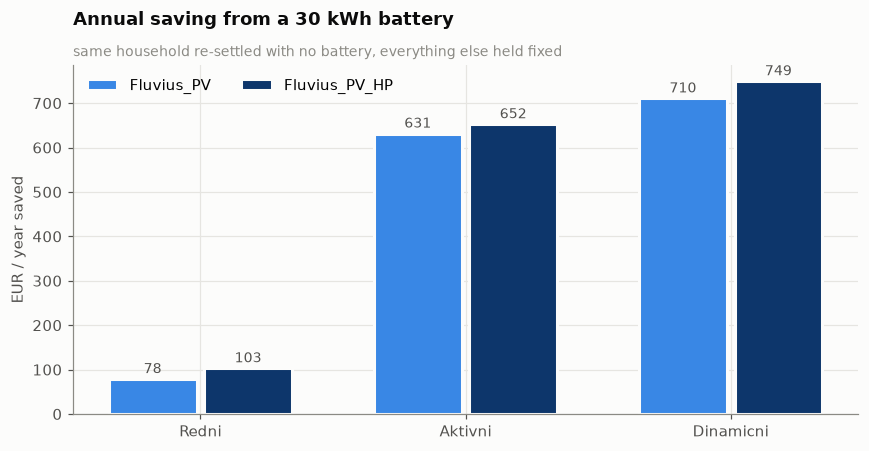

In [19]:
### What the 30 kWh battery is worth
fig, ax = plt.subplots(figsize=(8, 4.2))

saving = COUNTERFACTUAL.groupby(["Scenario", "segment"])["Saving_EUR"].mean().unstack()
saving = saving.reindex([cs.SCENARIOS[s]["label"] for s in SCEN_ORDER if s != "souporaba"])
x = np.arange(len(saving))
width = 0.36

for i, seg in enumerate(saving.columns):
    ax.bar(x + (i - 0.5) * width, saving[seg], width=width * 0.92,
           color=SEG_COLOR[seg], edgecolor=SURFACE, linewidth=2, label=seg)
    for xi, val in zip(x + (i - 0.5) * width, saving[seg]):
        ax.annotate(f"{val:,.0f}", (xi, val), xytext=(0, 4),
                    textcoords="offset points", ha="center", fontsize=9, color=INK_2)

ax.set_xticks(x)
ax.set_xticklabels(saving.index)
ax.yaxis.set_major_formatter(EUR)
ax.legend(ncol=2, loc="upper left")
finish(ax, "Annual saving from a 30 kWh battery",
       "same household re-settled with no battery, everything else held fixed",
       ylabel="EUR / year saved")
plt.tight_layout()
plt.show()

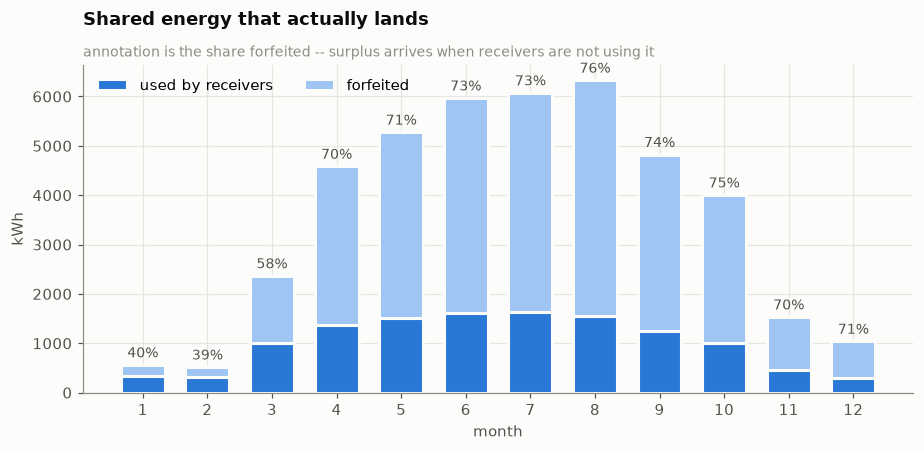

In [20]:
### Souporaba: shared energy used vs forfeited, by month
monthly = RESULTS["souporaba"]["monthly"]
recv = monthly[monthly["role"] == "prejemnik"].groupby("month")[
    ["deljeno_kwh", "neizrabljeno_kwh"]
].sum()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(recv.index, recv["deljeno_kwh"], width=0.68, color=SERIES[0],
       edgecolor=SURFACE, linewidth=2, label="used by receivers")
ax.bar(recv.index, recv["neizrabljeno_kwh"], bottom=recv["deljeno_kwh"], width=0.68,
       color=BLUES[1], edgecolor=SURFACE, linewidth=2, label="forfeited")

share = 100 * recv["neizrabljeno_kwh"] / (recv["deljeno_kwh"] + recv["neizrabljeno_kwh"])
for m, pct in share.items():
    total = recv.loc[m].sum()
    ax.annotate(f"{pct:.0f}%", (m, total), xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=9, color=INK_2)

ax.set_xticks(range(1, 13))
ax.legend(ncol=2, loc="upper left")
finish(ax, "Shared energy that actually lands",
       "annotation is the share forfeited -- surplus arrives when receivers are not using it",
       xlabel="month", ylabel="kWh")
plt.tight_layout()
plt.show()

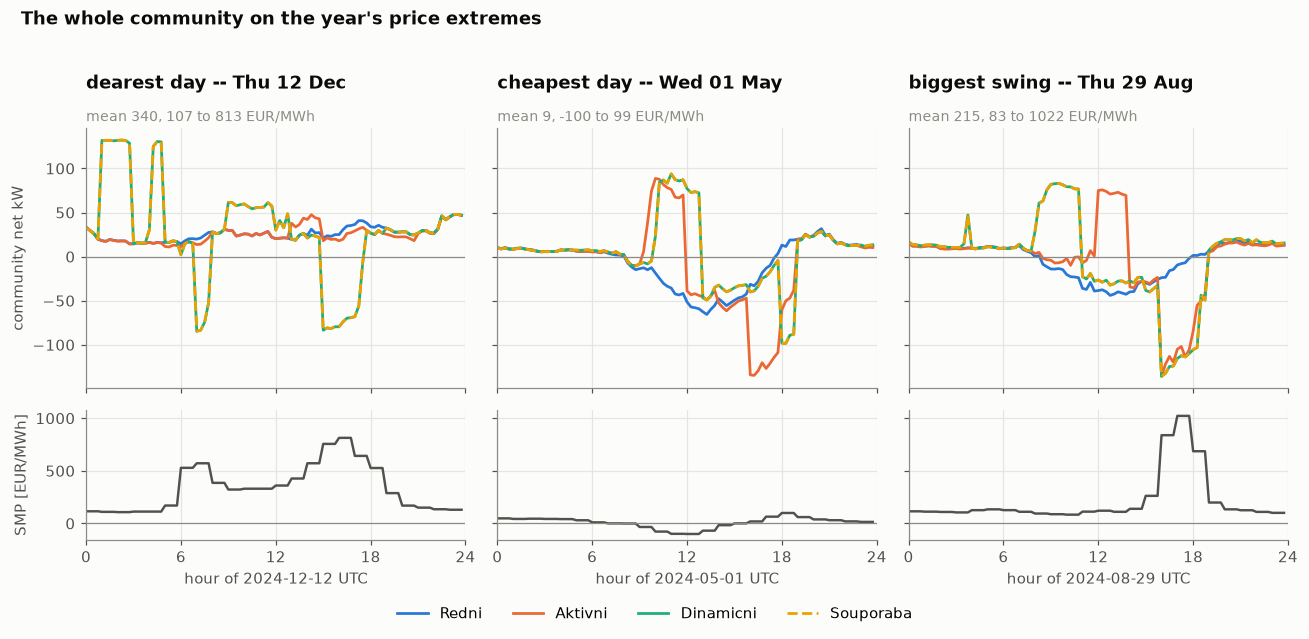

,mean,min,max,range,day
Timestamp_UTC,,,,,
2024-12-12 00:00:00+00:00,340.2,107.4,813.3,705.9,dearest day
2024-05-01 00:00:00+00:00,8.7,-100.2,99.3,199.6,cheapest day
2024-08-29 00:00:00+00:00,215.1,83.4,1022.3,938.9,biggest swing


In [21]:
### The whole community on the year's price extremes
# The SMP series is identical for every household, but it is read off the
# community profile's own index so the slicing stays positional -- the Fluvius
# files repeat the DST fall-back hour, so the index carries duplicate labels.
ref_index = RESULTS[SCEN_ORDER[0]]["community_profile"].index
smp = pd.Series(
    next(iter(DATA.values()))[cs.PRICE_COLUMN].to_numpy(dtype=float)[: len(ref_index)] * 1000.0,
    index=ref_index,
)
day_of = ref_index.normalize()
daily = smp.groupby(day_of).agg(["mean", "min", "max"])
daily["range"] = daily["max"] - daily["min"]

# Dearest and cheapest go by the daily mean -- a single interval says nothing
# about what a day cost the community. The swing is the intra-day range, which
# is what a battery actually earns on. Ties are broken by taking the runner-up,
# so the three panels are always three different days.
picks = []
for label, column, ascending in [("dearest day", "mean", False),
                                 ("cheapest day", "mean", True),
                                 ("biggest swing", "range", False)]:
    order = daily[column].sort_values(ascending=ascending).index
    picks.append((label, next(d for d in order if d not in [p[1] for p in picks])))

interval_hours = 24.0 / cs.STEPS_PER_DAY
fig, axes = plt.subplots(2, 3, figsize=(12, 5.8), sharex="col", sharey="row",
                         gridspec_kw={"height_ratios": [2, 1]})

for col, (label, day) in enumerate(picks):
    ax, axp = axes[0, col], axes[1, col]
    mask = (ref_index >= day) & (ref_index < day + pd.Timedelta(days=1))
    hours = (ref_index[mask] - day).total_seconds() / 3600.0

    for scenario in SCEN_ORDER:
        window = RESULTS[scenario]["community_profile"].loc[mask]
        # Net position of the community as a whole: everyone's import minus
        # everyone's export, so PV feeding a neighbour nets out instead of
        # counting twice.
        net_kw = (window["community_import_kwh"].to_numpy(dtype=float)
                  - window["community_export_kwh"].to_numpy(dtype=float)) / interval_hours
        ax.plot(hours, net_kw, color=SCEN_COLOR[scenario], linewidth=1.8,
                linestyle="--" if scenario == "souporaba" else "-",
                label=LABEL[scenario] if col == 0 else None)

    ax.axhline(0, color=MUTED, linewidth=0.8)
    row = daily.loc[day]
    finish(ax, f"{label} -- {day:%a %d %b}",
           f"mean {row['mean']:.0f}, {row['min']:.0f} to {row['max']:.0f} EUR/MWh",
           ylabel="community net kW" if col == 0 else None)

    axp.plot(hours, smp.loc[mask].to_numpy(dtype=float), color=INK_2, linewidth=1.6)
    axp.axhline(0, color=MUTED, linewidth=0.8)
    axp.set_xlim(0, 24)
    axp.set_xticks([0, 6, 12, 18, 24])
    axp.set_xlabel(f"hour of {day:%Y-%m-%d} UTC")
    if col == 0:
        axp.set_ylabel("SMP [EUR/MWh]")

# Figure-level legend: inside the first panel it would sit on top of the very
# curves it names -- these days are full from top to bottom.
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=4, loc="lower center", bbox_to_anchor=(0.5, 0.0))
fig.suptitle("The whole community on the year's price extremes", x=0.02, ha="left",
             fontsize=12, fontweight="semibold", color=INK)
plt.tight_layout(rect=(0, 0.05, 1, 0.96))
plt.show()

daily.loc[[d for _, d in picks]].assign(day=[l for l, _ in picks]).round(1)

## 9. Read-out

In [22]:
### The whole study in one block of text
lines = []
best = TOTALS.loc[TOTALS["Total_EUR"].idxmin()]
worst = TOTALS.loc[TOTALS["Total_EUR"].idxmax()]
gap_eur = best["Total_EUR"] * cs.hc.FULL_PERIOD_GAP_REL

lines.append(f"COMMUNITY OF {len(MEMBERS)} HOUSEHOLDS, YEAR {next(iter(DATA.values())).index[0]:%Y}")
lines.append("")
lines.append(f"{'scenario':14s}{'EUR/a':>11s}{'EUR/MWh':>10s}{'peak kW':>10s}{'diversity':>11s}")
for _, row in TOTALS.iterrows():
    lines.append(f"{row['Scenario']:14s}{row['Total_EUR']:11,.0f}"
                 f"{row['EUR_per_MWh']:10.1f}{row['Community_Peak_kW']:10.1f}"
                 f"{row['Diversity_Factor']:11.2f}")
lines.append("")
lines.append(f"Cheapest: {best['Scenario']} at {best['Total_EUR']:,.0f} EUR/a.")
lines.append(f"Dearest:  {worst['Scenario']} at {worst['Total_EUR']:,.0f} EUR/a "
             f"(+{worst['Total_EUR'] - best['Total_EUR']:,.0f} EUR, "
             f"{100 * (worst['Total_EUR'] / best['Total_EUR'] - 1):.1f} %).")

close = TOTALS[abs(TOTALS["Total_EUR"] - best["Total_EUR"]) < gap_eur]
if len(close) > 1:
    lines.append(f"NOT RESOLVABLE: {', '.join(close['Scenario'])} land within the solver's "
                 f"{cs.hc.FULL_PERIOD_GAP_REL:.1%} gap ({gap_eur:,.0f} EUR) of each other.")

lines.append("")
lines.append("PEAK POWER")
pk = TOTALS.loc[TOTALS["Community_Peak_kW"].idxmax()]
lines.append(f"  Highest coincident peak {pk['Community_Peak_kW']:.1f} kW "
             f"under {pk['Scenario']}, at {pk['Peak_At']:%Y-%m-%d %H:%M} UTC.")
lines.append(f"  The 50 individual peaks sum to {pk['Sum_Individual_Peaks_kW']:.0f} kW, so the "
             f"community draws only {pk['Diversity_Factor']:.0%} of what its members are")
lines.append(f"  billed for -- the power charge is levied per household, not on this peak.")
lo = TOTALS.loc[TOTALS["Community_Peak_kW"].idxmin()]
lines.append(f"  Tariff choice moves the peak more than anything else here: {lo['Scenario']} peaks at "
             f"{lo['Community_Peak_kW']:.0f} kW,")
lines.append(f"  {pk['Scenario']} at {pk['Community_Peak_kW']:.0f} kW -- "
             f"{pk['Community_Peak_kW'] / lo['Community_Peak_kW']:.1f}x. Under a flat tariff the battery only")
lines.append(f"  shaves; under a price-following one it charges hard from the grid when energy is")
lines.append(f"  cheap. Ten 11 kW inverters acting together is worth ~110 kW of new peak, and the")
lines.append(f"  excess-power charge is not steep enough to stop them.")

lines.append("")
lines.append("EXTREMES")
for _, row in EXTREMES.iterrows():
    driver = []
    if row["Battery_kWh"] > 0:
        driver.append(f"{row['Battery_kWh']:.0f} kWh battery")
    if row["Produced_kWh"] > 0:
        driver.append(f"{row['Produced_kWh']:,.0f} kWh PV")
    else:
        driver.append("no PV")
    driver.append(f"peak {row['Peak_over_Contract']:.1f}x contract")
    lines.append(f"  {row['Scenario']:11s} {row['Extreme']:8s} {row['household_id']:20s}"
                 f"{row['Cost_EUR']:8,.0f} EUR  ({row['Consumed_kWh']:,.0f} kWh load, "
                 f"{', '.join(driver)})")

lines.append("")
lines.append("BATTERY")
for scen, grp in COUNTERFACTUAL.groupby("Scenario", sort=False):
    lines.append(f"  {scen:11s} mean saving {grp['Saving_EUR'].mean():7,.0f} EUR/a "
                 f"(range {grp['Saving_EUR'].min():,.0f} to {grp['Saving_EUR'].max():,.0f})")

lines.append("")
lines.append("SOUPORABA")
lines.append(f"  {shared:,.0f} kWh shared, {used:,.0f} kWh used ({100 * used / shared:.0f} %), "
             f"{wasted:,.0f} kWh forfeited.")
sou_total = float(TOTALS.loc[TOTALS['scenario'] == 'souporaba', 'Total_EUR'].iloc[0])
din_total = float(TOTALS.loc[TOTALS['scenario'] == 'dinamicni', 'Total_EUR'].iloc[0])
lines.append(f"  Against the same dispatch on plain Dinamični: "
             f"{sou_total - din_total:+,.0f} EUR/a for the community.")
lines.append(f"  Receivers pay for every kWh transferred, used or not "
             f"(placilo_za_neizrabljeno=True):")
lines.append(f"    {wasted:,.0f} kWh forfeited x {cs.SOUPORABA_CENA_EUR_KWH} EUR/kWh"
             f" = {wasted * cs.SOUPORABA_CENA_EUR_KWH:,.0f} EUR paid for energy that never landed.")
n_send = int((sou_members['role'] == 'oddajnik').sum())
n_recv = int((sou_members['role'] == 'prejemnik').sum())
svc = cs.STORITVE_SOUPORABE[cs.SOUPORABA_SERVICE_ID]
fees = 12 * (n_send * svc.nadomestilo_oddajnik + n_recv * svc.nadomestilo_prejemnik)
lines.append(f"    organizer fees {n_send} x {svc.nadomestilo_oddajnik} + "
             f"{n_recv} x {svc.nadomestilo_prejemnik} EUR/month = {fees:,.0f} EUR/a.")
lines.append(f"  The rest is senders giving up the market buyback on the shared 40 %.")

print("\n".join(lines))

COMMUNITY OF 50 HOUSEHOLDS, YEAR 2024

scenario            EUR/a   EUR/MWh   peak kW  diversity
Redni              28,884     181.2      63.0       0.21
Aktivni            27,061     169.8     152.5       0.41
Dinamicni          23,005     144.4     152.8       0.40
Souporaba          39,789     249.7     152.8       0.40

Cheapest: Dinamicni at 23,005 EUR/a.
Dearest:  Souporaba at 39,789 EUR/a (+16,784 EUR, 73.0 %).

PEAK POWER
  Highest coincident peak 152.8 kW under Dinamicni, at 2024-01-29 00:00 UTC.
  The 50 individual peaks sum to 386 kW, so the community draws only 40% of what its members are
  billed for -- the power charge is levied per household, not on this peak.
  Tariff choice moves the peak more than anything else here: Redni peaks at 63 kW,
  Dinamicni at 153 kW -- 2.4x. Under a flat tariff the battery only
  shaves; under a price-following one it charges hard from the grid when energy is
  cheap. Ten 11 kW inverters acting together is worth ~110 kW of new peak, and the


### What this does and does not show

- **The MILP optimizes each battery household against its own bill.** It knows nothing about
  souporaba revenue or about the other members. The souporaba figures are a settlement laid
  *on top of* a selfishly-optimized dispatch, not a community optimum. A genuine community
  optimum would need a joint MILP over all members — `CommunityEnvironment` is the hook, and
  it is still uncoupled.
- **No shared community battery.** `COMMUNITY_BATTERY_KWH` is a placeholder; the only storage
  here is the ten household batteries. There is no inter-household energy transfer outside the
  souporaba settlement.
- **Battery households report zero `lastna_raba_kwh`.** Their trajectory is handed to the
  settlement as an equivalent (consumption, generation) pair that reproduces the *net* flow.
  The bill is exact; the self-consumption diagnostic is not recoverable from it.
- **Two excess-power formulas coexist.** The MILP objective uses the `si_konica` ratchet; the
  invoices use the regulated monthly `sqrt(sum d^2)`. That pre-existing discrepancy is
  inherited here — it affects the excess-power line, not the energy cost.
- **2024 data, 2026 tariffs.** `PRICING_REFERENCE_YEAR = 2026`, as in every other study in
  this repo: the Fluvius year predates the published Slovenian tariff acts.
- **The solver gap is 0.1 %.** Scenario differences smaller than that are not resolvable, and
  the read-out says so explicitly rather than declaring a winner. The forty households without
  a battery are priced exactly — no solver is involved for them.
- **Souporaba shares a fixed 40 % of surplus**, allocated equally across all receivers,
  regardless of whether they can use it. That is what produces the forfeited share; a
  demand-following allocation key would do better and is not modelled.
- **Every Fluvius file double-records the DST fall-back hour.** All 50 have 35 136 rows but
  only 35 132 distinct timestamps — `2024-10-27 02:00`–`02:45` UTC each appear twice. The
  intervals are real energy and are priced, so nothing is lost; but the index carries duplicate
  labels, which is why the community profile is summed *positionally* rather than by pandas
  alignment (`multi_household_tools.run_interval_scenario`,
  `Community_Study._community_profile`). Any new code that does `.loc[timestamp]` on these
  frames will get two rows back for those four instants.